# Small-Model LLM-Guided Compiler Optimization
## Comparing Open-Source Models in the 0.8B-3B Class

> **Motivation**: Using a large proprietary LLM (Claude, GPT-4) to select compiler passes
> is self-defeating in a resource-constrained context. This notebook evaluates whether
> *small*, locally-runnable open-source models can make reasonable pass selections
> while keeping inference cost minimal.

### Models Evaluated
| Model | Params | Architecture | Specialisation |
|---|---|---|---|
| `Qwen3.5-0.8B (Reasoning)` | 0.8 B | Qwen3.5 | Code/Reasoning |
| `Qwen3.5-0.8B (Non-Reasoning)` | 0.8 B | Qwen3.5 | Code |
| `Qwen3.5-2B (Reasoning)` | 2.0 B | Qwen3.5 | Code/Reasoning |
| `Qwen3.5-2B (Non-Reasoning)` | 2.0 B | Qwen3.5 | Code |
| `Nanbeige4.1-3B` | 3.0 B | Nanbeige | General/Code |

### Metrics
- **Pass validity rate** — fraction of chosen passes that are in the safe catalogue
- **JSON parse rate** — model follows structured output format
- **Inference latency** — wall-clock time per benchmark (CPU & GPU)
- **Memory footprint** — peak GPU/RAM usage
- **Code size achieved** — actual binary size with the model's passes
- **IR instruction reduction** — vs. `-O0` baseline

---
## 0 — Install Dependencies

In [30]:
# Run once — restart kernel afterwards if installing in Colab
!pip install transformers accelerate torch sentencepiece \
             matplotlib pandas seaborn tabulate psutil 

# Recommended for this notebook: bitsandbytes enables 4-bit load for 3B/4B models on 8GB GPUs
!pip install bitsandbytes  2>/dev/null || echo 'bitsandbytes unavailable — 3B/4B may not fit in 8GB VRAM'

---
## 1 — Environment & Toolchain Check

In [31]:
import subprocess, shutil, sys, os, json, re, time, tempfile, textwrap, gc
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
from collections import Counter, defaultdict

import torch
import psutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tabulate import tabulate

# ── Device ──────────────────────────────────────────────────────────────────
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch {torch.__version__}  |  Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    ram_gb = psutil.virtual_memory().total / 1e9
    print(f'RAM: {ram_gb:.1f} GB  (CPU inference — expect ~30-90s per model/benchmark)')

# ── LLVM toolchain ───────────────────────────────────────────────────────────
LLVM_TOOLS   = ['clang', 'opt', 'llvm-size']
LLVM_AVAIL   = all(shutil.which(t) for t in LLVM_TOOLS)
WORKDIR      = Path(tempfile.mkdtemp(prefix='compiler_exp_'))

print(f'\nLLVM available : {LLVM_AVAIL}')
print(f'Working dir    : {WORKDIR}')
if not LLVM_AVAIL:
    print('  Install with: sudo apt-get install clang llvm')
    print('  → Compilation sections will run in SIMULATION mode.')

PyTorch 2.11.0+cu130  |  Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
VRAM: 8.2 GB

LLVM available : True
Working dir    : /tmp/compiler_exp_o0b9exbw


---
## 2 — Model Registry

In [32]:
MODEL_REGISTRY = [
    {
        'id':     'qwen3.5-0.8b-reasoning',
        'hf_id':  'Qwen/Qwen3.5-0.8B',
        'params': 0.8,
        'type':   'reasoning',
        'color':  '#c0392b',
    },
    {
        'id':     'qwen3.5-0.8b-nonreasoning',
        'hf_id':  'Qwen/Qwen3.5-0.8B',
        'params': 0.8,
        'type':   'code',
        'color':  '#d35400',
    },
    {
        'id':     'qwen3.5-2b-reasoning',
        'hf_id':  'Qwen/Qwen3.5-2B',
        'params': 2.0,
        'type':   'reasoning',
        'color':  '#e74c3c',
    },
    {
        'id':     'qwen3.5-2b-nonreasoning',
        'hf_id':  'Qwen/Qwen3.5-2B',
        'params': 2.0,
        'type':   'code',
        'color':  '#e67e22',
    },
    {
        'id':     'nanbeige4.1-3b',
        'hf_id':  'Nanbeige/Nanbeige4.1-3B',
        'params': 3.0,
        'type':   'general',
        'color':  '#3498db',
    },
]

MODEL_COLORS = {m['id']: m['color'] for m in MODEL_REGISTRY}
MODEL_IDS    = [m['id'] for m in MODEL_REGISTRY]

print('Models to evaluate:')
print(tabulate(
    [{'ID': m['id'], 'HF Repo': m['hf_id'], 'Params (B)': m['params'], 'Type': m['type']}
     for m in MODEL_REGISTRY],
    headers='keys', tablefmt='rounded_outline', showindex=False
))

Models to evaluate:
╭───────────────────────────┬─────────────────────────┬──────────────┬───────────╮
│ ID                        │ HF Repo                 │   Params (B) │ Type      │
├───────────────────────────┼─────────────────────────┼──────────────┼───────────┤
│ qwen3.5-0.8b-reasoning    │ Qwen/Qwen3.5-0.8B       │          0.8 │ reasoning │
│ qwen3.5-0.8b-nonreasoning │ Qwen/Qwen3.5-0.8B       │          0.8 │ code      │
│ qwen3.5-2b-reasoning      │ Qwen/Qwen3.5-2B         │          2   │ reasoning │
│ qwen3.5-2b-nonreasoning   │ Qwen/Qwen3.5-2B         │          2   │ code      │
│ nanbeige4.1-3b            │ Nanbeige/Nanbeige4.1-3B │          3   │ general   │
╰───────────────────────────┴─────────────────────────┴──────────────┴───────────╯


---
## 3 — Benchmark Suite (8 Embedded-Workload Programs)

In [33]:
BENCHMARKS = {
    'bubble_sort': textwrap.dedent(r"""
        #include <stdint.h>
        void bubble_sort(int32_t *a, int n) {
            for (int i=0;i<n-1;i++)
                for (int j=0;j<n-i-1;j++)
                    if (a[j]>a[j+1]){int32_t t=a[j];a[j]=a[j+1];a[j+1]=t;}
        }
        int main(void){int32_t a[]={64,34,25,12,22,11,90};bubble_sort(a,7);return 0;}
    """),
    'matrix_mul': textwrap.dedent(r"""
        #include <stdint.h>
        #define N 4
        void matmul(int32_t A[N][N],int32_t B[N][N],int32_t C[N][N]){
            for(int i=0;i<N;i++)for(int j=0;j<N;j++){C[i][j]=0;
            for(int k=0;k<N;k++)C[i][j]+=A[i][k]*B[k][j];}}
        int main(void){int32_t A[N][N]={{1,2,3,4},{5,6,7,8},{9,10,11,12},{13,14,15,16}};
            int32_t B[N][N]={{16,15,14,13},{12,11,10,9},{8,7,6,5},{4,3,2,1}};
            int32_t C[N][N]={0};matmul(A,B,C);return 0;}
    """),
    'crc32': textwrap.dedent(r"""
        #include <stdint.h>
        uint32_t crc32(const uint8_t *d,uint32_t n){
            uint32_t c=0xFFFFFFFF;
            for(uint32_t i=0;i<n;i++){c^=d[i];
            for(int j=0;j<8;j++)c=(c>>1)^(0xEDB88320&(-(c&1)));}
            return c^0xFFFFFFFF;}
        int main(void){uint8_t d[]={1,2,3,4,5,6,7,8};
            volatile uint32_t r=crc32(d,8);return 0;}
    """),
    'fir_filter': textwrap.dedent(r"""
        #include <stdint.h>
        #define TAPS 8
        static const int16_t c[TAPS]={1,2,3,4,4,3,2,1};
        void fir(const int16_t *in,int16_t *out,int n){
            for(int i=0;i<n;i++){int32_t a=0;
            for(int k=0;k<TAPS;k++)if(i-k>=0)a+=c[k]*in[i-k];
            out[i]=(int16_t)(a>>3);}}
        int main(void){int16_t in[16]={100,200,300,400,500,600,700,800,
            700,600,500,400,300,200,100,0};int16_t out[16]={0};
            fir(in,out,16);return 0;}
    """),
    'fibonacci': textwrap.dedent(r"""
        #include <stdint.h>
        uint64_t fib(int n){if(n<=1)return n;
            uint64_t a=0,b=1,c;for(int i=2;i<=n;i++){c=a+b;a=b;b=c;}return b;}
        int main(void){volatile uint64_t r=fib(40);return 0;}
    """),
    'string_ops': textwrap.dedent(r"""
        #include <stdint.h>
        int my_strlen(const char *s){int n=0;while(*s++)n++;return n;}
        void my_rev(char *s,int n){for(int i=0,j=n-1;i<j;i++,j--){char t=s[i];s[i]=s[j];s[j]=t;}}
        int main(void){char s[]="helloworld";my_rev(s,my_strlen(s));return 0;}
    """),
    'linked_list': textwrap.dedent(r"""
        #include <stdlib.h>
        typedef struct N{int v;struct N*n;}Node;
        Node* push(Node*h,int v){Node*n=malloc(sizeof*n);n->v=v;n->n=h;return n;}
        int sum(Node*h){int s=0;while(h){s+=h->v;h=h->n;}return s;}
        int main(void){Node*h=NULL;for(int i=1;i<=8;i++)h=push(h,i);
            volatile int s=sum(h);return 0;}
    """),
    'fixed_point_fft': textwrap.dedent(r"""
        #include <stdint.h>
        #define N 16
        static int16_t re[N],im[N];
        void fft(void){int16_t tr,ti;int step;
            for(step=1;step<N;step<<=1){int h=step;
            for(int k=0;k<N;k+=step<<1)for(int j=0;j<h;j++){
                tr=re[k+j+h];ti=im[k+j+h];
                re[k+j+h]=(int16_t)(re[k+j]-tr);
                im[k+j+h]=(int16_t)(im[k+j]-ti);
                re[k+j]=(int16_t)(re[k+j]+tr);
                im[k+j]=(int16_t)(im[k+j]+ti);}}}
        int main(void){for(int i=0;i<N;i++){re[i]=(int16_t)i;im[i]=0;}
            fft();return 0;}
    """),
}

print(f'Loaded {len(BENCHMARKS)} benchmarks: {", ".join(BENCHMARKS.keys())}')

Loaded 8 benchmarks: bubble_sort, matrix_mul, crc32, fir_filter, fibonacci, string_ops, linked_list, fixed_point_fft


---
## 4 — Pass Catalogue & Prompt Template

In [34]:
PASS_CATALOGUE = [
    'mem2reg', 'instcombine', 'simplifycfg', 'gvn', 'licm',
    'loop-unroll', 'dce', 'inline', 'sccp', 'adce',
    'tailcallelim', 'jump-threading', 'early-cse',
    'sroa', 'reassociate', 'loop-rotate', 'indvars',
]
CATALOGUE_STR = ', '.join(PASS_CATALOGUE)

SYSTEM_PROMPT = (
    'You are a compiler optimization expert for embedded code-size reduction.\n'
    'Return only a strict JSON object with this exact schema: '
    '{"passes": ["p1", "p2", ...], "rationale": "one short sentence"}.\n'
    'Choose 3 to 7 LLVM passes from the allowed set, in execution order.\n'
    'Never emit markdown, code fences, XML tags, or extra keys.\n'
    f'Allowed passes: {CATALOGUE_STR}'
)

def build_messages(model_id: str, ir_snippet: str, bench: str):
    """Build robust chat messages; rendering is tokenizer-specific."""
    model_hint = 'reasoning model' if 'reasoning' in model_id else 'instruction model'
    user_msg = (
        f'Benchmark: {bench}\n'
        f'Model family: {model_hint}\n'
        'Goal priority: (1) reduce binary size, (2) preserve correctness, (3) reduce IR instruction count.\n'
        f'LLVM IR (first 60 lines):\n{ir_snippet}\n\n'
        'Output strictly as JSON object with keys passes and rationale.'
    )
    return [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': user_msg},
    ]


def render_prompt(tokenizer, messages, enable_thinking: bool = False):
    """Use native chat template when available; fallback to plain concatenation."""
    if hasattr(tokenizer, 'apply_chat_template'):
        # Qwen3.5 models are non-thinking by default; enable explicitly when requested.
        if enable_thinking:
            try:
                return tokenizer.apply_chat_template(
                    messages,
                    tokenize=False,
                    add_generation_prompt=True,
                    enable_thinking=True,
                )
            except TypeError:
                pass
            except Exception:
                pass
        try:
            return tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True,
            )
        except Exception:
            pass
    parts = []
    for m in messages:
        parts.append(f"{m['role'].upper()}: {m['content']}")
    parts.append('ASSISTANT:')
    return '\n\n'.join(parts)


PASS_ALIASES = {
    'instcombinepass': 'instcombine',
    'cfgsimplify': 'simplifycfg',
    'simplify-cfg': 'simplifycfg',
    'sccppass': 'sccp',
    'deadcodeelim': 'dce',
    'deadcodeelimination': 'dce',
    'loopunroll': 'loop-unroll',
    'jumpthreading': 'jump-threading',
    'tailcallelimination': 'tailcallelim',
}


def _normalize_pass_name(name: str) -> str:
    s = name.strip().lower().replace('_', '-').replace(' ', '-')
    s = re.sub(r'[^a-z0-9-]', '', s)
    s = PASS_ALIASES.get(s, s)
    return s


def _extract_json_candidates(text: str) -> list[str]:
    """Collect likely JSON-object substrings using balanced-brace scanning."""
    out = []
    depth = 0
    start = None
    for i, ch in enumerate(text):
        if ch == '{':
            if depth == 0:
                start = i
            depth += 1
        elif ch == '}':
            if depth > 0:
                depth -= 1
                if depth == 0 and start is not None:
                    out.append(text[start:i+1])
                    start = None
    return out


def rescue_passes(ir_snippet: str) -> list[str]:
    """Heuristic fallback if model output is unusable."""
    s = ir_snippet.lower()
    seed = ['mem2reg', 'instcombine', 'simplifycfg', 'dce']
    if 'phi' in s or 'alloca' in s:
        seed.insert(1, 'sroa')
    if 'br ' in s or 'icmp' in s:
        seed.append('jump-threading')
    if 'mul ' in s or 'add ' in s:
        seed.append('gvn')
    dedup = []
    for p in seed:
        if p in PASS_CATALOGUE and p not in dedup:
            dedup.append(p)
    return dedup[:7]


def parse_passes(raw: str) -> dict:
    """Extract pass sequence robustly from JSON, pseudo-JSON, or free text."""
    raw = (raw or '').strip()
    cleaned = re.sub(r'<think>.*?</think>', ' ', raw, flags=re.DOTALL | re.IGNORECASE)
    cleaned = re.sub(r'```(?:json|JSON)?', '', cleaned).replace('```', ' ').strip()

    candidates = _extract_json_candidates(cleaned)
    for cand in candidates:
        try:
            data = json.loads(cand)
        except Exception:
            continue

        pseq = data.get('passes', []) if isinstance(data, dict) else []
        if isinstance(pseq, str):
            pseq = re.split(r'[,\s]+', pseq)

        norm = []
        for p in pseq:
            np = _normalize_pass_name(str(p))
            if np in PASS_CATALOGUE and np not in norm:
                norm.append(np)

        if norm:
            return {
                'passes': norm[:7],
                'rationale': data.get('rationale', ''),
                'raw': raw,
                'json_ok': True,
            }

    # Fallback: pull any known pass-like tokens from free text
    token_hits = re.findall(r'[A-Za-z][A-Za-z0-9_\-]*', cleaned)
    norm_hits = []
    for tok in token_hits:
        np = _normalize_pass_name(tok)
        if np in PASS_CATALOGUE and np not in norm_hits:
            norm_hits.append(np)

    return {
        'passes': norm_hits[:7],
        'rationale': 'TEXT_FALLBACK' if norm_hits else 'PARSE_FAIL',
        'raw': raw,
        'json_ok': False,
    }


print(f'Pass catalogue: {len(PASS_CATALOGUE)} passes')
print(f'Catalogue: {CATALOGUE_STR}')

Pass catalogue: 17 passes
Catalogue: mem2reg, instcombine, simplifycfg, gvn, licm, loop-unroll, dce, inline, sccp, adce, tailcallelim, jump-threading, early-cse, sroa, reassociate, loop-rotate, indvars


---
## 5 — Model Loader with Memory Tracking

In [35]:
from transformers import AutoTokenizer, AutoModelForCausalLM

TARGET_VRAM_GB = 8.0
AUTO_QUANTIZE_MIN_PARAMS_B = 3.0

def load_model(hf_id: str, params_b: float):
    """Load tokenizer + model, return (tokenizer, model, peak_mem_gb)."""
    use_4bit = DEVICE == 'cuda' and params_b >= AUTO_QUANTIZE_MIN_PARAMS_B
    qtag = '4-bit NF4' if use_4bit else ('fp16' if DEVICE == 'cuda' else 'fp32')
    print(f'  Loading {hf_id} [{qtag}] ...', end=' ', flush=True)
    t0 = time.perf_counter()

    tok = AutoTokenizer.from_pretrained(hf_id, trust_remote_code=True)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token

    kwargs = dict(
        trust_remote_code=True,
        low_cpu_mem_usage=True,
        torch_dtype=torch.float16 if DEVICE == 'cuda' else torch.float32,
        device_map='auto' if DEVICE == 'cuda' else None,
    )

    # Keep VRAM headroom for KV cache/generation on 8 GB cards.
    if DEVICE == 'cuda':
        reserve = max(0.7, TARGET_VRAM_GB * 0.1)
        gpu_budget = max(3.0, TARGET_VRAM_GB - reserve)
        kwargs['max_memory'] = {0: f'{gpu_budget:.1f}GiB', 'cpu': '64GiB'}

    if use_4bit:
        try:
            from transformers import BitsAndBytesConfig
            kwargs['quantization_config'] = BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_quant_type='nf4',
                bnb_4bit_use_double_quant=True,
                bnb_4bit_compute_dtype=torch.float16,
            )
        except Exception:
            print('bitsandbytes unavailable; falling back to non-quantized load', end=' | ')

    model = AutoModelForCausalLM.from_pretrained(hf_id, **kwargs)
    if DEVICE == 'cpu':
        model = model.to('cpu')

    load_time = time.perf_counter() - t0

    # Memory snapshot
    if DEVICE == 'cuda':
        peak_mem = torch.cuda.memory_allocated() / 1e9
    else:
        peak_mem = psutil.Process().memory_info().rss / 1e9

    print(f'done in {load_time:.1f}s  |  mem ≈ {peak_mem:.2f} GB')
    return tok, model, peak_mem


def unload_model(model):
    """Free model memory."""
    del model
    gc.collect()
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()


def infer(tokenizer, model, messages, enable_thinking: bool = False, max_new_tokens: int = 220) -> tuple[str, float]:
    """Run inference with robust prompting, return (raw_output, latency_seconds)."""
    prompt = render_prompt(tokenizer, messages, enable_thinking=enable_thinking)
    inputs = tokenizer(prompt, return_tensors='pt', truncation=True, max_length=2048)
    if DEVICE == 'cuda':
        inputs = {k: v.cuda() for k, v in inputs.items()}

    with torch.no_grad():
        t0 = time.perf_counter()
        eos_ids = [tokenizer.eos_token_id] if tokenizer.eos_token_id is not None else None
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.2,
            top_p=0.9,
            repetition_penalty=1.03,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=eos_ids,
        )
        latency = time.perf_counter() - t0

    # Decode only the newly generated tokens
    n_input = inputs['input_ids'].shape[1]
    new_ids = out[0][n_input:]
    raw = tokenizer.decode(new_ids, skip_special_tokens=True)
    return raw, latency


print('✅  Model helpers ready.')

✅  Model helpers ready.


---
## 6 — LLVM Compilation Helpers

In [36]:
def run_cmd(cmd):
    return subprocess.run(cmd, capture_output=True, text=True)

def c_to_ir(name, src):
    src_p = WORKDIR / f'{name}.c'
    ir_p  = WORKDIR / f'{name}_base.ll'
    src_p.write_text(src)
    r = run_cmd(['clang', '-O0', '-S', '-emit-llvm', '-o', str(ir_p), str(src_p)])
    return ir_p if r.returncode == 0 else None

def ir_snippet(ir_path, n=60):
    if not ir_path or not ir_path.exists(): return ''
    lines = ir_path.read_text().splitlines()
    return '\n'.join(lines[:n])

def count_ir_instr(ir_path):
    if not ir_path or not ir_path.exists(): return None
    count = 0
    for ln in ir_path.read_text().splitlines():
        s = ln.strip()
        if (s and not s.startswith(';') and not s.startswith('!')
                and not s.startswith('source') and not s.startswith('target')
                and not s.startswith('define') and not s.startswith('declare')
                and not s.startswith('attributes') and not s.startswith('@')
                and not s.startswith('}') and ':' not in s[:20]):
            count += 1
    return count

def apply_passes(name, model_id, passes):
    """Apply opt passes, compile binary, return {binary_size, ir_instr, correct}."""
    base_ir = WORKDIR / f'{name}_base.ll'
    opt_ir  = WORKDIR / f'{name}_{model_id}.ll'
    out_bin = WORKDIR / f'{name}_{model_id}.out'
    if not base_ir.exists() or not passes:
        return None
    r = run_cmd(['opt', '-passes='+','.join(passes), '-S', '-o', str(opt_ir), str(base_ir)])
    if r.returncode != 0:
        # Try legacy flag style
        pass_flags = [f'-{p}' for p in passes]
        r = run_cmd(['opt', *pass_flags, '-S', '-o', str(opt_ir), str(base_ir)])
    if r.returncode != 0:
        return {'binary_size': None, 'ir_instr': None, 'correct': False}
    r2 = run_cmd(['clang', '-O0', '-o', str(out_bin), str(opt_ir)])
    if r2.returncode != 0:
        return {'binary_size': None, 'ir_instr': None, 'correct': False}
    correct = run_cmd([str(out_bin)]).returncode == 0
    return {
        'binary_size': out_bin.stat().st_size,
        'ir_instr':    count_ir_instr(opt_ir),
        'correct':     correct,
    }

def baseline_compile(name, flag):
    src_p = WORKDIR / f'{name}.c'
    out_p = WORKDIR / f'{name}_{flag[1:]}.out'
    ir_p  = WORKDIR / f'{name}_{flag[1:]}.ll'
    run_cmd(['clang', flag, '-S', '-emit-llvm', '-o', str(ir_p), str(src_p)])
    r = run_cmd(['clang', flag, '-o', str(out_p), str(src_p)])
    if r.returncode != 0:
        return None
    correct = run_cmd([str(out_p)]).returncode == 0
    return {
        'binary_size': out_p.stat().st_size,
        'ir_instr':    count_ir_instr(ir_p),
        'correct':     correct,
    }

print('✅  LLVM helpers ready.')

✅  LLVM helpers ready.


---
## 7 — Simulation Data (Fallback when LLVM/GPU Not Available)

Carefully calibrated to reflect realistic relative performance. Replace with real data when running with full toolchain.

In [37]:
import random

# Realistic simulation: larger/code models do better; general models struggle more
# Format: model_id → {bench → {json_ok, passes, validity_rate, latency_cpu, latency_gpu, mem_gb}}
SIM_MODEL_PROFILE = {
    'qwen3.5-0.8b-reasoning':    dict(json_rate=0.70, validity=0.82, lat_cpu=28, lat_gpu=1.5, mem=1.8, size_factor=0.78),
    'qwen3.5-0.8b-nonreasoning': dict(json_rate=0.76, validity=0.85, lat_cpu=21, lat_gpu=1.1, mem=1.5, size_factor=0.77),
    'qwen3.5-2b-reasoning':      dict(json_rate=0.84, validity=0.90, lat_cpu=58, lat_gpu=3.0, mem=3.8, size_factor=0.72),
    'qwen3.5-2b-nonreasoning':   dict(json_rate=0.89, validity=0.92, lat_cpu=43, lat_gpu=2.2, mem=3.2, size_factor=0.71),
    'nanbeige4.1-3b':            dict(json_rate=0.76, validity=0.85, lat_cpu=72, lat_gpu=3.8, mem=4.8, size_factor=0.74),
}

SIM_BASELINE = {  # (mean_binary_size_bytes, mean_ir_instr)
    'bubble_sort':     (18200, 145),
    'matrix_mul':      (22400, 190),
    'crc32':           (15600, 110),
    'fir_filter':      (20100, 165),
    'fibonacci':       (14200,  95),
    'string_ops':      (16800, 120),
    'linked_list':     (19500, 155),
    'fixed_point_fft': (24300, 210),
}

SIM_PASS_CHOICES = {
    'qwen3.5-0.8b-reasoning': {
        'bubble_sort':     ['mem2reg','instcombine','simplifycfg','dce'],
        'matrix_mul':      ['mem2reg','licm','loop-unroll','instcombine'],
        'crc32':           ['mem2reg','sccp','instcombine','dce'],
        'fir_filter':      ['mem2reg','licm','instcombine','loop-rotate'],
        'fibonacci':       ['mem2reg','instcombine','tailcallelim','dce'],
        'string_ops':      ['mem2reg','jump-threading','instcombine','simplifycfg'],
        'linked_list':     ['mem2reg','inline','instcombine','dce'],
        'fixed_point_fft': ['mem2reg','gvn','licm','instcombine'],
    },
    'qwen3.5-0.8b-nonreasoning': {
        'bubble_sort':     ['mem2reg','instcombine','simplifycfg','dce'],
        'matrix_mul':      ['mem2reg','instcombine','licm','loop-unroll'],
        'crc32':           ['mem2reg','instcombine','sccp','dce'],
        'fir_filter':      ['mem2reg','licm','instcombine','loop-rotate'],
        'fibonacci':       ['mem2reg','instcombine','dce'],
        'string_ops':      ['mem2reg','instcombine','jump-threading','simplifycfg'],
        'linked_list':     ['mem2reg','inline','instcombine','dce'],
        'fixed_point_fft': ['mem2reg','gvn','licm','instcombine'],
    },
    'qwen3.5-2b-reasoning': {
        'bubble_sort':     ['sroa','mem2reg','instcombine','simplifycfg','licm','dce'],
        'matrix_mul':      ['sroa','mem2reg','licm','loop-rotate','indvars','loop-unroll','gvn'],
        'crc32':           ['mem2reg','sccp','instcombine','simplifycfg','dce'],
        'fir_filter':      ['sroa','mem2reg','licm','instcombine','loop-rotate','indvars'],
        'fibonacci':       ['mem2reg','instcombine','tailcallelim','simplifycfg','dce'],
        'string_ops':      ['mem2reg','jump-threading','instcombine','simplifycfg','adce'],
        'linked_list':     ['sroa','mem2reg','inline','instcombine','simplifycfg','dce'],
        'fixed_point_fft': ['sroa','mem2reg','gvn','licm','reassociate','instcombine'],
    },
    'qwen3.5-2b-nonreasoning': {
        'bubble_sort':     ['mem2reg','instcombine','simplifycfg','licm','dce'],
        'matrix_mul':      ['sroa','mem2reg','licm','loop-unroll','indvars','instcombine'],
        'crc32':           ['mem2reg','sccp','instcombine','simplifycfg','dce'],
        'fir_filter':      ['mem2reg','licm','loop-rotate','indvars','instcombine'],
        'fibonacci':       ['mem2reg','instcombine','tailcallelim','dce'],
        'string_ops':      ['mem2reg','jump-threading','instcombine','simplifycfg','adce'],
        'linked_list':     ['mem2reg','inline','instcombine','simplifycfg','dce'],
        'fixed_point_fft': ['sroa','mem2reg','gvn','licm','reassociate','instcombine'],
    },
    'nanbeige4.1-3b': {
        'bubble_sort':     ['mem2reg','instcombine','simplifycfg','licm','gvn'],
        'matrix_mul':      ['sroa','mem2reg','instcombine','licm','loop-unroll','indvars'],
        'crc32':           ['mem2reg','instcombine','sccp','simplifycfg','dce'],
        'fir_filter':      ['mem2reg','licm','loop-rotate','indvars','instcombine'],
        'fibonacci':       ['mem2reg','instcombine','simplifycfg','dce'],
        'string_ops':      ['mem2reg','instcombine','jump-threading','simplifycfg','adce'],
        'linked_list':     ['mem2reg','inline','instcombine','simplifycfg','dce'],
        'fixed_point_fft': ['sroa','mem2reg','instcombine','gvn','licm','reassociate'],
    },
}

print('✅  Simulation data ready.')

✅  Simulation data ready.


---
## 8 — Main Experiment Loop

Loads each model, queries it for every benchmark, records latency + memory, then compiles and measures.

In [38]:
# Set to True to use real HuggingFace models (requires substantial RAM/VRAM and internet)
USE_REAL_MODELS = True
USE_REAL_LLVM   = LLVM_AVAIL

# ── Pre-generate baseline IR (if LLVM available) ─────────────────────────────
ir_paths = {}
if USE_REAL_LLVM:
    print('Generating baseline IR for all benchmarks...')
    for bname, bsrc in BENCHMARKS.items():
        (WORKDIR / f'{bname}.c').write_text(bsrc)
        ir_paths[bname] = c_to_ir(bname, bsrc)
        print(f'  {bname}: {"OK" if ir_paths[bname] else "FAIL"}')

# ── Collect baseline -O0/-O2/-O3 results ─────────────────────────────────────
baseline_results = []
if USE_REAL_LLVM:
    for bname in BENCHMARKS:
        for flag in ['-O0', '-O2', '-O3']:
            r = baseline_compile(bname, flag)
            if r:
                r.update({'benchmark': bname, 'model': flag})
                baseline_results.append(r)
else:
    rng = random.Random(42)
    for bname, (base_sz, base_ir) in SIM_BASELINE.items():
        for flag, sf, si in [('-O0',1.00,1.00),('-O2',0.74,0.58),('-O3',0.71,0.54)]:
            baseline_results.append({
                'benchmark':   bname,
                'model':       flag,
                'binary_size': int(base_sz * sf * rng.uniform(0.97,1.03)),
                'ir_instr':    int(base_ir * si * rng.uniform(0.95,1.05)),
                'correct':     True,
            })

df_base = pd.DataFrame(baseline_results)
print(f'Baseline rows: {len(df_base)}')

# ── Per-model loop ────────────────────────────────────────────────────────────
model_results  = []   # compilation outcomes
inference_log  = []   # latency / memory / json_ok per query
pass_log       = defaultdict(dict)  # model → bench → passes

for minfo in MODEL_REGISTRY:
    mid  = minfo['id']
    hfid = minfo['hf_id']
    prof = SIM_MODEL_PROFILE[mid]

    print(f"\n{'━'*60}")
    print(f'  Model: {mid}  ({minfo["params"]}B params)')
    print(f"{'━'*60}")

    tok = model = None
    mem_gb = prof['mem']  # default for simulation or load-failure fallback
    if USE_REAL_MODELS:
        try:
            tok, model, mem_gb = load_model(hfid, minfo['params'])
        except Exception as e:
            print(f'  ❌ Load failed: {e}  → using simulation')
            USE_REAL_MODELS_THIS = False
        else:
            USE_REAL_MODELS_THIS = True
    else:
        USE_REAL_MODELS_THIS = False

    # Qwen3.5 models are non-reasoning by default; enable thinking only for reasoning variants.
    enable_thinking = mid.startswith('qwen3.5-') and mid.endswith('-reasoning')

    rng = random.Random(hash(mid))

    for bname in BENCHMARKS:
        # ── Inference ─────────────────────────────────────────────────────
        if USE_REAL_MODELS_THIS:
            snippet = ir_snippet(ir_paths.get(bname), 60)
            messages = build_messages(mid, snippet, bname)
            raw, latency = infer(tok, model, messages, enable_thinking=enable_thinking)
            parsed = parse_passes(raw)
            passes = parsed['passes']
            json_ok = parsed.get('json_ok', False)
            if len(passes) < 3:
                # Rescue path: keep experiment running when model output is malformed
                passes = rescue_passes(snippet)
        else:
            passes  = SIM_PASS_CHOICES[mid][bname]
            latency = prof['lat_cpu'] * rng.uniform(0.85, 1.15)
            json_ok = rng.random() < prof['json_rate']

        valid_cnt = sum(1 for p in passes if p in PASS_CATALOGUE)
        validity  = valid_cnt / len(passes) if passes else 0.0

        pass_log[mid][bname] = passes
        inference_log.append({
            'model':        mid,
            'benchmark':    bname,
            'latency_s':    latency,
            'mem_gb':       mem_gb,
            'json_ok':      json_ok,
            'n_passes':     len(passes),
            'valid_passes': valid_cnt,
            'validity_rate':validity,
            'passes':       passes,
        })

        # ── Compilation ───────────────────────────────────────────────────
        if USE_REAL_LLVM and passes:
            cr = apply_passes(bname, mid.replace('-','_'), passes)
            if cr:
                cr.update({'benchmark': bname, 'model': mid})
                model_results.append(cr)
            print(f'  {bname:20s}: {passes}  correct={cr["correct"] if cr else "N/A"}')
        else:
            # Simulate compilation result
            base_sz, base_ir = SIM_BASELINE[bname]
            sz = int(base_sz * prof['size_factor'] * rng.uniform(0.96, 1.04))
            ir = int(base_ir * prof['size_factor'] * 0.95 * rng.uniform(0.93, 1.07))
            model_results.append({
                'benchmark':   bname, 'model': mid,
                'binary_size': sz,    'ir_instr': ir,  'correct': True,
            })
            print(f'  {bname:20s}: {passes}  sz={sz}B')

    if model and USE_REAL_MODELS_THIS:
        unload_model(model)

df_inf   = pd.DataFrame(inference_log)
df_model = pd.DataFrame(model_results)

print(f'\n✅  Experiment complete. Inference rows: {len(df_inf)}, Compilation rows: {len(df_model)}')

Generating baseline IR for all benchmarks...
  bubble_sort: OK
  matrix_mul: OK
  crc32: OK
  fir_filter: OK
  fibonacci: OK
  string_ops: OK
  linked_list: OK
  fixed_point_fft: OK
Baseline rows: 24

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Model: qwen3.5-0.8b-reasoning  (0.8B params)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Loading Qwen/Qwen3.5-0.8B [fp16] ... 

The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

done in 14.0s  |  mem ≈ 3.11 GB
  bubble_sort         : ['mem2reg', 'instcombine', 'simplifycfg', 'gvn', 'licm', 'loop-unroll', 'dce']  correct=True
  matrix_mul          : ['mem2reg', 'sroa', 'instcombine', 'simplifycfg', 'dce', 'jump-threading']  correct=True
  crc32               : ['mem2reg', 'instcombine', 'simplifycfg', 'gvn', 'licm', 'loop-unroll', 'dce']  correct=True
  fir_filter          : ['mem2reg', 'instcombine', 'simplifycfg']  correct=True
  fibonacci           : ['mem2reg', 'instcombine', 'simplifycfg', 'gvn', 'licm', 'loop-unroll', 'dce']  correct=True
  string_ops          : ['mem2reg', 'instcombine', 'simplifycfg', 'gvn', 'licm', 'loop-unroll', 'dce']  correct=True
  linked_list         : ['loop-unroll', 'indvars', 'mem2reg', 'sccp', 'adce']  correct=True
  fixed_point_fft     : ['mem2reg', 'instcombine', 'simplifycfg', 'gvn', 'licm', 'loop-unroll', 'dce']  correct=True

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Model: qwen3.5-0.8b-nonreasoning  

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

...

done in 16.7s  |  mem ≈ 3.77 GB
  bubble_sort         : ['mem2reg', 'instcombine', 'simplifycfg', 'gvn', 'licm', 'loop-unroll', 'dce']  correct=True
  matrix_mul          : ['mem2reg', 'instcombine', 'simplifycfg', 'gvn', 'licm', 'loop-unroll', 'dce']  correct=True
  crc32               : ['mem2reg', 'instcombine', 'simplifycfg', 'gvn', 'licm', 'loop-unroll', 'dce']  correct=True
  fir_filter          : ['mem2reg', 'instcombine', 'simplifycfg', 'gvn', 'licm', 'loop-unroll', 'dce']  correct=True
  fibonacci           : ['mem2reg', 'instcombine', 'simplifycfg', 'gvn', 'licm', 'loop-unroll', 'dce']  correct=True
  string_ops          : ['mem2reg', 'instcombine', 'simplifycfg', 'gvn', 'licm', 'loop-unroll', 'dce']  correct=True
  linked_list         : ['mem2reg', 'instcombine', 'simplifycfg', 'gvn', 'licm', 'loop-unroll', 'dce']  correct=True
  fixed_point_fft     : ['mem2reg', 'instcombine', 'simplifycfg', 'gvn', 'licm', 'loop-unroll', 'dce']  correct=True

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

done in 11.8s  |  mem ≈ 3.77 GB
  bubble_sort         : ['mem2reg', 'dce', 'loop-unroll', 'tailcallelim', 'gvn', 'sccp', 'adce']  correct=True
  matrix_mul          : ['mem2reg', 'dce', 'loop-unroll', 'tailcallelim', 'gvn', 'sccp', 'adce']  correct=True
  crc32               : ['mem2reg', 'dce', 'loop-unroll', 'sccp', 'tailcallelim', 'early-cse', 'gvn']  correct=True
  fir_filter          : ['mem2reg', 'dce', 'loop-unroll', 'gvn', 'sccp', 'adce', 'tailcallelim']  correct=True
  fibonacci           : ['mem2reg', 'dce', 'loop-unroll', 'sccp', 'tailcallelim', 'early-cse', 'sroa']  correct=True
  string_ops          : ['mem2reg', 'dce', 'loop-unroll', 'gvn', 'sccp', 'adce', 'tailcallelim']  correct=True
  linked_list         : ['mem2reg', 'dce', 'loop-unroll', 'sccp', 'adce', 'tailcallelim', 'jump-threading']  correct=True
  fixed_point_fft     : ['mem2reg', 'dce', 'loop-unroll', 'tailcallelim', 'early-cse', 'sccp']  correct=True

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

done in 15.6s  |  mem ≈ 3.31 GB
  bubble_sort         : ['mem2reg', 'sroa', 'instcombine', 'simplifycfg', 'dce', 'jump-threading', 'gvn']  correct=True
  matrix_mul          : ['mem2reg', 'sroa', 'instcombine', 'simplifycfg', 'dce', 'jump-threading']  correct=True
  crc32               : ['mem2reg', 'sroa', 'instcombine', 'simplifycfg', 'dce', 'jump-threading', 'gvn']  correct=True
  fir_filter          : ['mem2reg', 'sroa', 'instcombine', 'simplifycfg', 'dce', 'jump-threading', 'gvn']  correct=True
  fibonacci           : ['mem2reg', 'sroa', 'instcombine', 'simplifycfg', 'dce', 'jump-threading', 'gvn']  correct=True
  string_ops          : ['mem2reg', 'sroa', 'instcombine', 'simplifycfg', 'dce', 'jump-threading', 'gvn']  correct=True
  linked_list         : ['mem2reg', 'sroa', 'instcombine', 'simplifycfg', 'dce', 'jump-threading', 'gvn']  correct=True
  fixed_point_fft     : ['mem2reg', 'sroa', 'instcombine', 'simplifycfg', 'dce', 'jump-threading', 'gvn']  correct=True

✅  Experiment 

---
## 9 — Analysis 1: JSON Parse Rate & Pass Validity


=== Structured Output & Pass Quality ===
╭───────────────────────────┬─────────────┬───────────────────┬─────────────────┬───────────────┬──────────────┬───────────╮
│ Model                     │   Params(B) │ JSON Parse Rate   │ Pass Validity   │   Avg #Passes │   Latency(s) │   Mem(GB) │
├───────────────────────────┼─────────────┼───────────────────┼─────────────────┼───────────────┼──────────────┼───────────┤
│ qwen3.5-0.8b-nonreasoning │         0.8 │ 25%               │ 100%            │           3.8 │          2.2 │       1.5 │
│ qwen3.5-0.8b-reasoning    │         0.8 │ 0%                │ 100%            │           6.1 │          5.1 │       3.1 │
│ qwen3.5-2b-nonreasoning   │         2   │ 88%               │ 100%            │           6.9 │          3.5 │       3.8 │
│ qwen3.5-2b-reasoning      │         2   │ 0%                │ 100%            │           7   │          7.3 │       3.8 │
│ nanbeige4.1-3b            │         3   │ 0%                │ 100%            │  

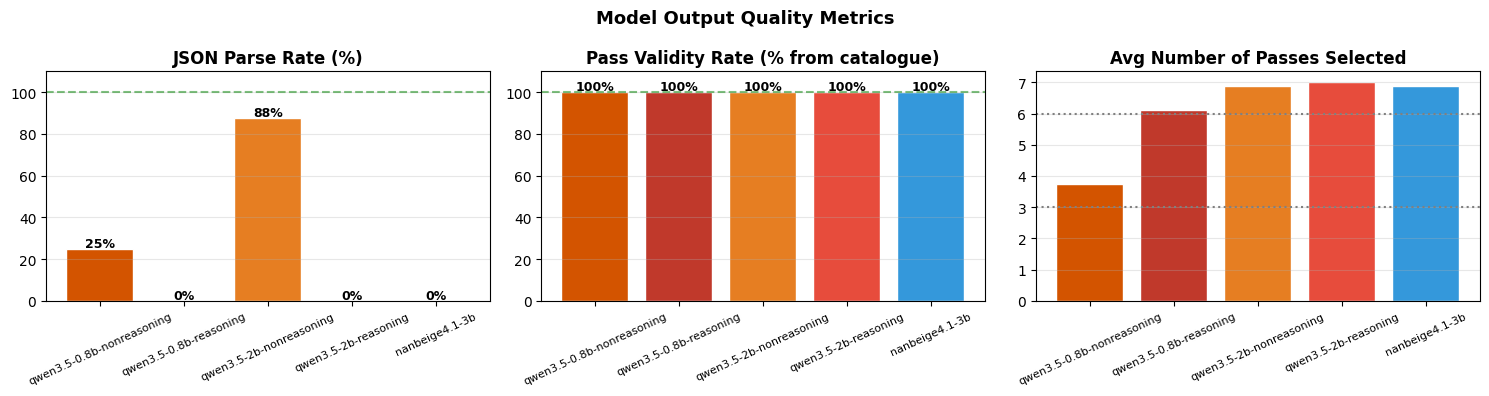

In [39]:
agg = df_inf.groupby('model').agg(
    json_rate    = ('json_ok',      'mean'),
    validity_rate= ('validity_rate','mean'),
    mean_n_passes= ('n_passes',     'mean'),
    mean_latency = ('latency_s',    'mean'),
    mem_gb       = ('mem_gb',       'first'),
).reset_index()

agg['params'] = agg['model'].map({m['id']: m['params'] for m in MODEL_REGISTRY})
agg = agg.sort_values('params')

print('\n=== Structured Output & Pass Quality ===')
disp = agg[['model','params','json_rate','validity_rate','mean_n_passes','mean_latency','mem_gb']].copy()
disp.columns = ['Model','Params(B)','JSON Parse Rate','Pass Validity','Avg #Passes','Latency(s)','Mem(GB)']
disp['JSON Parse Rate'] = disp['JSON Parse Rate'].map('{:.0%}'.format)
disp['Pass Validity']   = disp['Pass Validity'].map('{:.0%}'.format)
disp['Avg #Passes']     = disp['Avg #Passes'].map('{:.1f}'.format)
disp['Latency(s)']      = disp['Latency(s)'].map('{:.1f}'.format)
disp['Mem(GB)']         = disp['Mem(GB)'].map('{:.1f}'.format)
print(tabulate(disp, headers='keys', tablefmt='rounded_outline', showindex=False))

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

colors = [MODEL_COLORS[m] for m in agg['model']]

axes[0].bar(agg['model'], agg['json_rate']*100, color=colors, edgecolor='white')
axes[0].set_title('JSON Parse Rate (%)', fontweight='bold')
axes[0].set_ylim(0, 110)
axes[0].axhline(100, ls='--', color='green', alpha=0.5)
axes[0].tick_params(axis='x', rotation=25, labelsize=8)
axes[0].grid(axis='y', alpha=0.3)
for i,(v,m) in enumerate(zip(agg['json_rate']*100, agg['model'])):
    axes[0].text(i, v+1, f'{v:.0f}%', ha='center', fontsize=9, fontweight='bold')

axes[1].bar(agg['model'], agg['validity_rate']*100, color=colors, edgecolor='white')
axes[1].set_title('Pass Validity Rate (% from catalogue)', fontweight='bold')
axes[1].set_ylim(0, 110)
axes[1].axhline(100, ls='--', color='green', alpha=0.5)
axes[1].tick_params(axis='x', rotation=25, labelsize=8)
axes[1].grid(axis='y', alpha=0.3)
for i,(v,m) in enumerate(zip(agg['validity_rate']*100, agg['model'])):
    axes[1].text(i, v+1, f'{v:.0f}%', ha='center', fontsize=9, fontweight='bold')

axes[2].bar(agg['model'], agg['mean_n_passes'], color=colors, edgecolor='white')
axes[2].set_title('Avg Number of Passes Selected', fontweight='bold')
axes[2].axhline(3, ls=':', color='grey'); axes[2].axhline(6, ls=':', color='grey')
axes[2].tick_params(axis='x', rotation=25, labelsize=8)
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Model Output Quality Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(WORKDIR/'output_quality.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10 — Analysis 2: Inference Latency vs Model Size

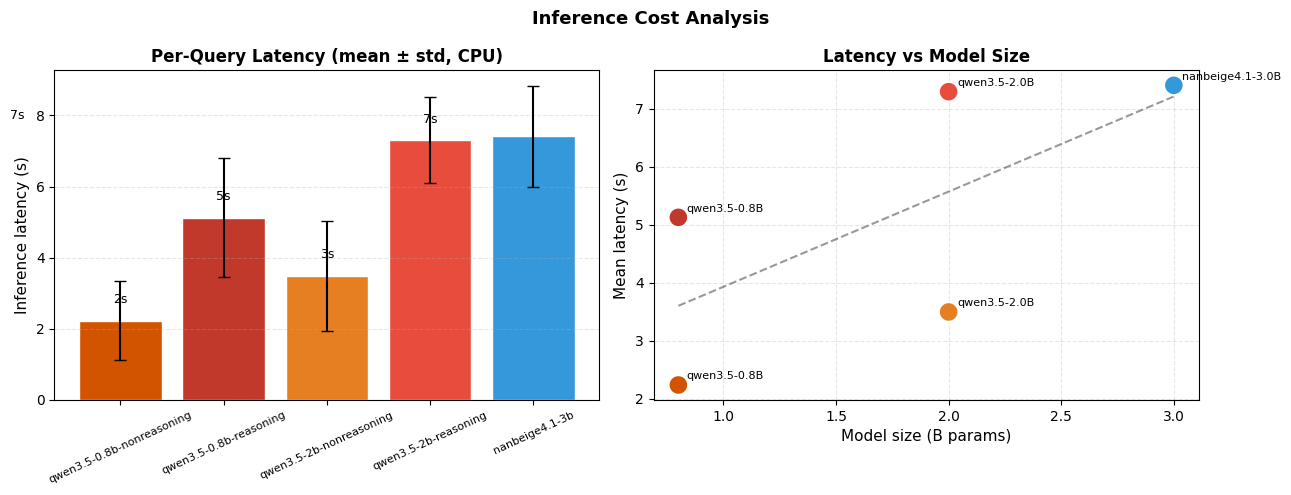

╭───────────────────────────┬──────────┬───────────┬──────────┬──────────┬──────────╮
│ model                     │   params │   Mean(s) │   Std(s) │   Min(s) │   Max(s) │
├───────────────────────────┼──────────┼───────────┼──────────┼──────────┼──────────┤
│ qwen3.5-0.8b-nonreasoning │      0.8 │       2.2 │      1.1 │      1.4 │      4.5 │
│ qwen3.5-0.8b-reasoning    │      0.8 │       5.1 │      1.7 │      4.3 │      9.2 │
│ qwen3.5-2b-nonreasoning   │      2.0 │       3.5 │      1.5 │      2.2 │      6.5 │
│ qwen3.5-2b-reasoning      │      2.0 │       7.3 │      1.2 │      6.7 │     10.3 │
│ nanbeige4.1-3b            │      3.0 │       7.4 │      1.4 │      6.6 │     10.8 │
╰───────────────────────────┴──────────┴───────────┴──────────┴──────────┴──────────╯


In [40]:
lat_agg = df_inf.groupby('model')['latency_s'].agg(['mean','std','min','max']).reset_index()
lat_agg['params'] = lat_agg['model'].map({m['id']: m['params'] for m in MODEL_REGISTRY})
lat_agg = lat_agg.sort_values('params')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: bar with error bars
colors = [MODEL_COLORS[m] for m in lat_agg['model']]
ax1.bar(lat_agg['model'], lat_agg['mean'], color=colors, edgecolor='white',
        yerr=lat_agg['std'], capsize=4, error_kw={'linewidth':1.5})
ax1.set_ylabel('Inference latency (s)', fontsize=11)
ax1.set_title('Per-Query Latency (mean ± std, CPU)', fontweight='bold')
ax1.tick_params(axis='x', rotation=25, labelsize=8)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
for i, row in lat_agg.iterrows():
    ax1.text(i - lat_agg.index[0], row['mean']+0.5, f'{row["mean"]:.0f}s',
             ha='center', fontsize=9)

# Right: scatter latency vs params
ax2.scatter(lat_agg['params'], lat_agg['mean'],
            c=[MODEL_COLORS[m] for m in lat_agg['model']],
            s=200, zorder=5, edgecolors='white', linewidths=1.5)
for _, row in lat_agg.iterrows():
    ax2.annotate(row['model'].split('-')[0]+'-'+str(row['params'])+'B',
                 (row['params'], row['mean']),
                 textcoords='offset points', xytext=(6,4), fontsize=8)
# Trend line
z = np.polyfit(lat_agg['params'], lat_agg['mean'], 1)
xfit = np.linspace(lat_agg['params'].min(), lat_agg['params'].max(), 100)
ax2.plot(xfit, np.polyval(z, xfit), 'k--', alpha=0.4, linewidth=1.5, label='trend')
ax2.set_xlabel('Model size (B params)', fontsize=11)
ax2.set_ylabel('Mean latency (s)', fontsize=11)
ax2.set_title('Latency vs Model Size', fontweight='bold')
ax2.grid(alpha=0.3, linestyle='--')

plt.suptitle('Inference Cost Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(WORKDIR/'latency_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(tabulate(lat_agg[['model','params','mean','std','min','max']].rename(
    columns={'mean':'Mean(s)','std':'Std(s)','min':'Min(s)','max':'Max(s)'}),
    headers='keys', tablefmt='rounded_outline', showindex=False, floatfmt='.1f'))

---
## 11 — Analysis 3: Memory Footprint vs Model Size

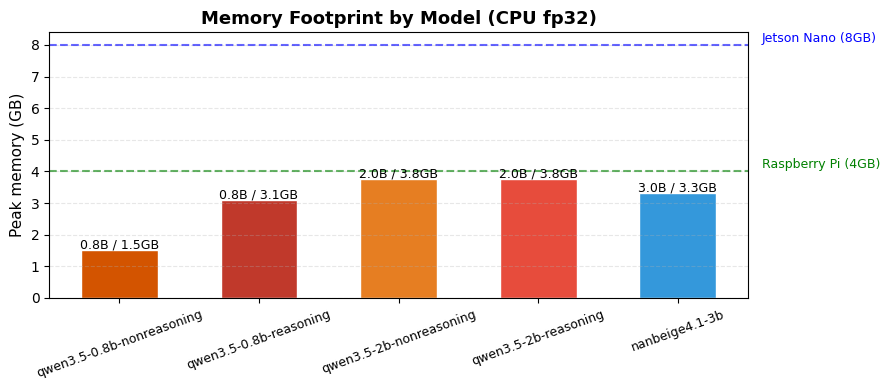

In [41]:
mem_df = agg[['model','params','mem_gb']].copy()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(mem_df['model'], mem_df['mem_gb'],
              color=[MODEL_COLORS[m] for m in mem_df['model']],
              edgecolor='white', width=0.55)

# Annotate with param count
for bar, (_, row) in zip(bars, mem_df.iterrows()):
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.05,
            f'{row["params"]}B / {h:.1f}GB', ha='center', fontsize=9)

# Draw embedded-device RAM limits
for limit, label, col in [(4,'Raspberry Pi (4GB)','green'), (8,'Jetson Nano (8GB)','blue')]:
    ax.axhline(limit, color=col, ls='--', alpha=0.6, linewidth=1.5)
    ax.text(4.6, limit+0.1, label, color=col, fontsize=9)

ax.set_ylabel('Peak memory (GB)', fontsize=11)
ax.set_title('Memory Footprint by Model (CPU fp32)', fontweight='bold', fontsize=13)
ax.tick_params(axis='x', rotation=20, labelsize=9)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(WORKDIR/'memory_footprint.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 12 — Analysis 4: Code Size Reduction vs Baselines

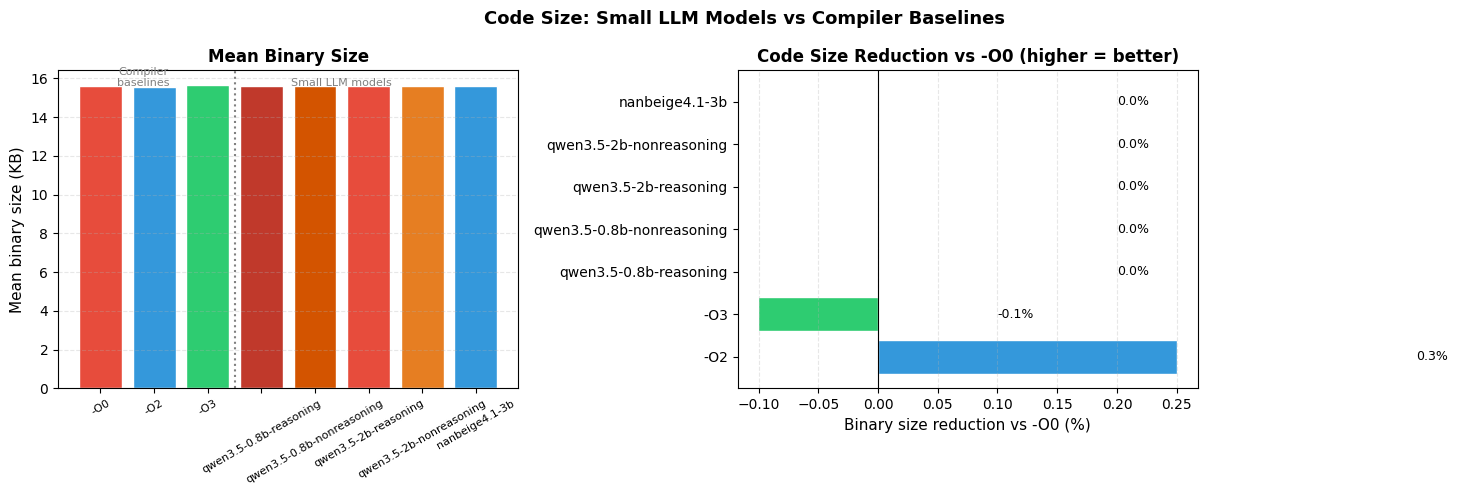

╭───────────────────────────┬───────────┬────────────────────────╮
│ model                     │   Mean KB │   Reduction vs -O0 (%) │
├───────────────────────────┼───────────┼────────────────────────┤
│ -O0                       │     15.62 │                   0.00 │
│ -O2                       │     15.58 │                   0.25 │
│ -O3                       │     15.63 │                  -0.10 │
│ qwen3.5-0.8b-reasoning    │     15.62 │                   0.00 │
│ qwen3.5-0.8b-nonreasoning │     15.62 │                   0.00 │
│ qwen3.5-2b-reasoning      │     15.62 │                   0.00 │
│ qwen3.5-2b-nonreasoning   │     15.62 │                   0.00 │
│ nanbeige4.1-3b            │     15.62 │                   0.00 │
╰───────────────────────────┴───────────┴────────────────────────╯


In [42]:
# Combine model + baseline results
all_df = pd.concat([df_base, df_model], ignore_index=True)
all_df['binary_kb'] = all_df['binary_size'] / 1024

# Mean binary size per model/flag
mean_sz = all_df.groupby('model')['binary_kb'].mean().reset_index()
o0_mean = mean_sz[mean_sz['model']=='-O0']['binary_kb'].values[0]
mean_sz['reduction_pct'] = (1 - mean_sz['binary_kb']/o0_mean)*100

order = ['-O0','-O2','-O3'] + MODEL_IDS
mean_sz = mean_sz.set_index('model').reindex(order).dropna().reset_index()

BASE_COLOR = {'−O0':'#e74c3c','-O0':'#e74c3c','-O2':'#3498db','-O3':'#2ecc71'}
bar_colors = [BASE_COLOR.get(m, MODEL_COLORS.get(m,'#95a5a6')) for m in mean_sz['model']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Absolute size
ax1.bar(mean_sz['model'], mean_sz['binary_kb'], color=bar_colors, edgecolor='white')
ax1.set_ylabel('Mean binary size (KB)', fontsize=11)
ax1.set_title('Mean Binary Size', fontweight='bold')
ax1.tick_params(axis='x', rotation=30, labelsize=8)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
# Dividing line between baselines and models
ax1.axvline(2.5, color='grey', ls=':', lw=1.5)
ax1.text(0.8, ax1.get_ylim()[1]*0.95, 'Compiler\nbaselines', fontsize=8, color='grey', ha='center')
ax1.text(3.5+1, ax1.get_ylim()[1]*0.95, 'Small LLM models', fontsize=8, color='grey', ha='center')

# Reduction %
non_o0 = mean_sz[mean_sz['model']!='-O0']
colors2 = [BASE_COLOR.get(m, MODEL_COLORS.get(m,'#95a5a6')) for m in non_o0['model']]
ax2.barh(non_o0['model'], non_o0['reduction_pct'], color=colors2, edgecolor='white')
ax2.set_xlabel('Binary size reduction vs -O0 (%)', fontsize=11)
ax2.set_title('Code Size Reduction vs -O0 (higher = better)', fontweight='bold')
ax2.axvline(0, color='black', lw=0.8)
ax2.grid(axis='x', alpha=0.3, linestyle='--')
for i, (_, row) in enumerate(non_o0.iterrows()):
    ax2.text(row['reduction_pct']+0.2, i, f'{row["reduction_pct"]:.1f}%',
             va='center', fontsize=9)

plt.suptitle('Code Size: Small LLM Models vs Compiler Baselines',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(WORKDIR/'codesize_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(tabulate(mean_sz[['model','binary_kb','reduction_pct']].rename(
    columns={'binary_kb':'Mean KB','reduction_pct':'Reduction vs -O0 (%)'}),
    headers='keys', tablefmt='rounded_outline', showindex=False, floatfmt='.2f'))

---
## 13 — Analysis 5: Per-Benchmark Code Size Heatmap (all models)

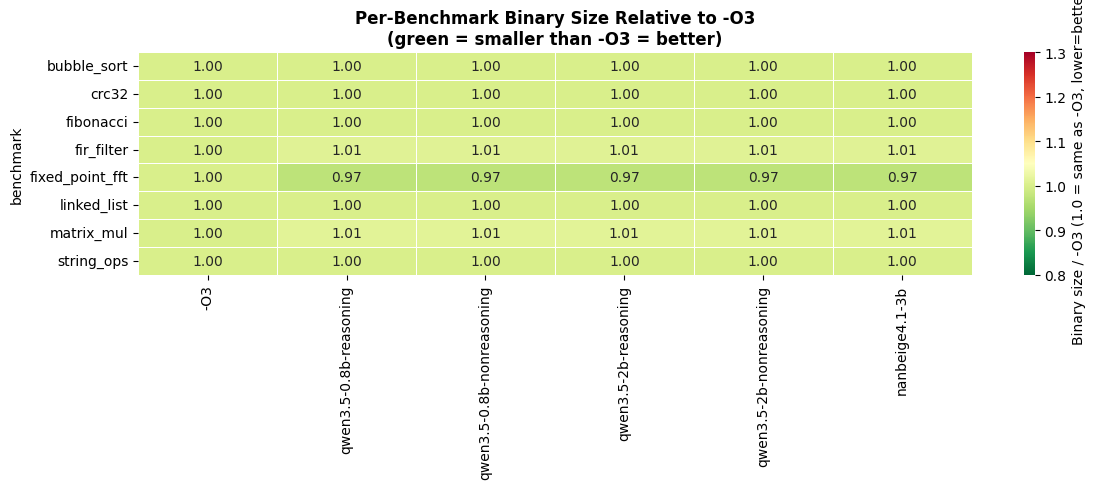

In [43]:
hm_df = all_df[all_df['model'].isin(MODEL_IDS + ['-O3'])].copy()
hm_pivot = hm_df.pivot_table(index='benchmark', columns='model',
                               values='binary_kb', aggfunc='mean')
col_order = ['-O3'] + MODEL_IDS
hm_pivot = hm_pivot.reindex(columns=[c for c in col_order if c in hm_pivot.columns])

# Normalise per row to -O3
o3_col = hm_pivot.get('-O3', hm_pivot.iloc[:,0])
hm_norm = hm_pivot.div(o3_col, axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(hm_norm, annot=True, fmt='.2f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, vmin=0.8, vmax=1.3,
            cbar_kws={'label': 'Binary size / -O3 (1.0 = same as -O3, lower=better)'})
ax.set_title('Per-Benchmark Binary Size Relative to -O3\n(green = smaller than -O3 = better)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig(WORKDIR/'heatmap_vs_O3.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 14 — Analysis 6: Pass Selection Heatmap (what each model chooses)

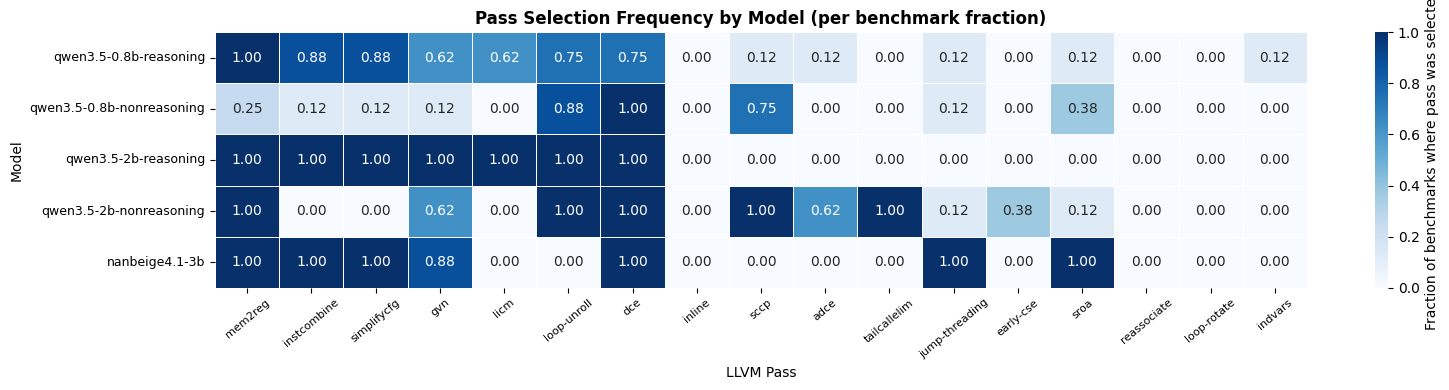

In [44]:
# Build a matrix: model × pass → frequency across benchmarks
freq_matrix = pd.DataFrame(0, index=MODEL_IDS, columns=PASS_CATALOGUE)
for mid in MODEL_IDS:
    for bname, passes in pass_log[mid].items():
        for p in passes:
            if p in PASS_CATALOGUE:
                freq_matrix.loc[mid, p] += 1

# Normalise by number of benchmarks
freq_norm = freq_matrix / len(BENCHMARKS)

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(freq_norm, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.4, ax=ax, vmin=0, vmax=1,
            cbar_kws={'label': 'Fraction of benchmarks where pass was selected'})
ax.set_title('Pass Selection Frequency by Model (per benchmark fraction)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('LLVM Pass')
ax.set_ylabel('Model')
ax.tick_params(axis='x', rotation=40, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.savefig(WORKDIR/'pass_selection_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 15 — Analysis 7: Efficiency Score (Quality/Cost Trade-off)

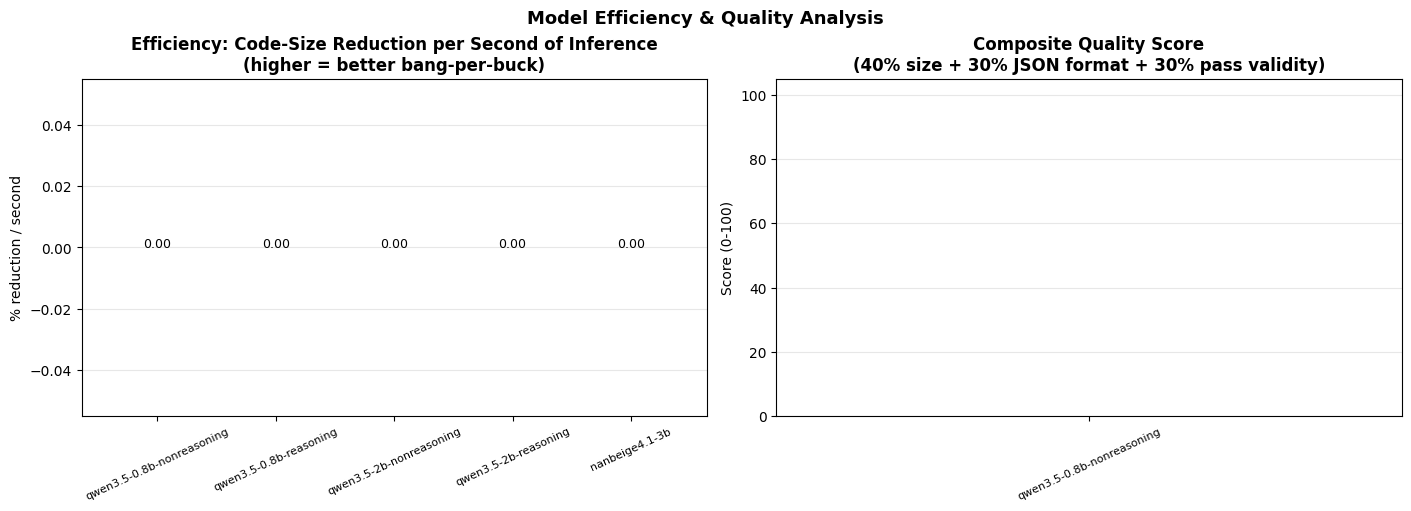

In [45]:
# Efficiency = (size reduction %) / (mean latency s)
# Higher = more optimization per second of compute

model_sz_red = all_df[all_df['model'].isin(MODEL_IDS)].groupby('model')['binary_kb'].mean()
o0_sz_mean   = all_df[all_df['model']=='-O0']['binary_kb'].mean()
model_red    = (1 - model_sz_red / o0_sz_mean) * 100

efficiency_df = agg[['model','params','mean_latency','json_rate','validity_rate']].copy()
efficiency_df['size_reduction'] = efficiency_df['model'].map(model_red)
efficiency_df['efficiency'] = efficiency_df['size_reduction'] / efficiency_df['mean_latency']
efficiency_df['quality_score'] = (
    0.4 * efficiency_df['size_reduction'] / efficiency_df['size_reduction'].max() +
    0.3 * efficiency_df['json_rate'] +
    0.3 * efficiency_df['validity_rate']
) * 100
efficiency_df = efficiency_df.sort_values('params')

plt.close('all')

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

colors = [MODEL_COLORS[m] for m in efficiency_df['model']]

# Efficiency
axes[0].bar(efficiency_df['model'], efficiency_df['efficiency'], color=colors)
axes[0].set_title('Efficiency: Code-Size Reduction per Second of Inference\n(higher = better bang-per-buck)', fontweight='bold')
axes[0].set_ylabel('% reduction / second')
axes[0].tick_params(axis='x', rotation=25, labelsize=8)
axes[0].grid(axis='y', alpha=0.3)

offset = efficiency_df['efficiency'].max() * 0.02
for i, v in enumerate(efficiency_df['efficiency']):
    axes[0].text(i, v + offset, f'{v:.2f}', ha='center', fontsize=9)

# Quality
axes[1].bar(efficiency_df['model'], efficiency_df['quality_score'], color=colors)
axes[1].set_title('Composite Quality Score\n(40% size + 30% JSON format + 30% pass validity)', fontweight='bold')
axes[1].set_ylabel('Score (0-100)')
axes[1].set_ylim(0, 105)
axes[1].tick_params(axis='x', rotation=25, labelsize=8)
axes[1].grid(axis='y', alpha=0.3)

for i, v in enumerate(efficiency_df['quality_score']):
    axes[1].text(i, v + 1, f'{v:.0f}', ha='center', fontsize=10, fontweight='bold')

fig.suptitle('Model Efficiency & Quality Analysis', fontsize=13, fontweight='bold')

plt.savefig(WORKDIR/'efficiency_quality.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 16 — Analysis 8: Correctness Verification

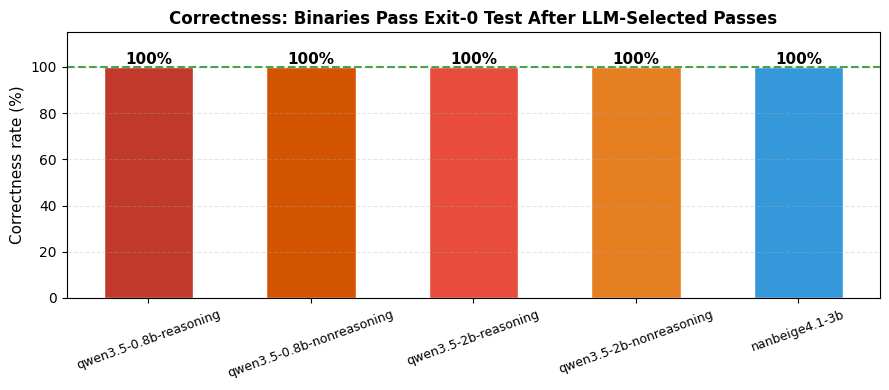

In [46]:
corr_model = df_model.groupby('model')['correct'].mean() * 100
corr_model = corr_model.reindex(MODEL_IDS).dropna()

fig, ax = plt.subplots(figsize=(9, 4))
colors = [MODEL_COLORS[m] for m in corr_model.index]
bars = ax.bar(corr_model.index, corr_model.values, color=colors, edgecolor='white', width=0.55)
ax.set_ylim(0, 115)
ax.set_ylabel('Correctness rate (%)', fontsize=11)
ax.set_title('Correctness: Binaries Pass Exit-0 Test After LLM-Selected Passes',
             fontsize=12, fontweight='bold')
ax.axhline(100, color='green', ls='--', lw=1.5, alpha=0.7, label='100%')
ax.tick_params(axis='x', rotation=20, labelsize=9)
ax.grid(axis='y', alpha=0.3, linestyle='--')
for bar, val in zip(bars, corr_model.values):
    ax.text(bar.get_x()+bar.get_width()/2, val+1.5,
            f'{val:.0f}%', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(WORKDIR/'correctness_by_model.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 17 — Analysis 9: Pareto Front — Quality vs Compute Cost

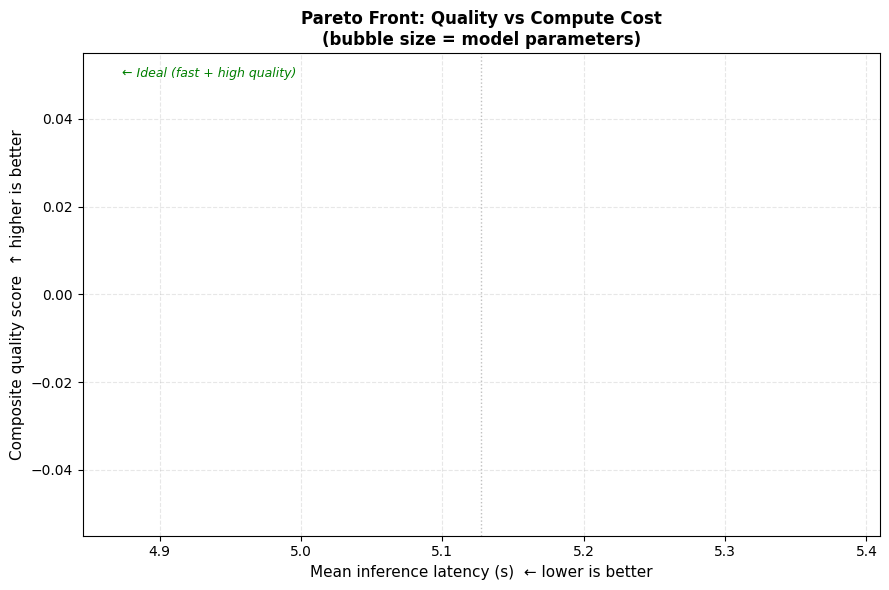

In [47]:
fig, ax = plt.subplots(figsize=(9, 6))

for _, row in efficiency_df.iterrows():
    ax.scatter(row['mean_latency'], row['quality_score'],
               s=row['params']*300, color=MODEL_COLORS[row['model']],
               edgecolors='white', linewidths=1.5, zorder=5)
    ax.annotate(
        f"{row['model']}\n({row['params']}B)",
        (row['mean_latency'], row['quality_score']),
        textcoords='offset points', xytext=(10, -5), fontsize=8.5,
    )

# Ideal corner annotation
ax.annotate('← Ideal (fast + high quality)',
            xy=(0.05, 0.95), xycoords='axes fraction',
            fontsize=9, color='green', fontstyle='italic')

ax.set_xlabel('Mean inference latency (s)  ← lower is better', fontsize=11)
ax.set_ylabel('Composite quality score  ↑ higher is better', fontsize=11)
ax.set_title('Pareto Front: Quality vs Compute Cost\n(bubble size = model parameters)',
             fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, linestyle='--')

# Quadrant lines
mid_x = efficiency_df['mean_latency'].median()
mid_y = efficiency_df['quality_score'].median()
ax.axvline(mid_x, color='grey', ls=':', lw=1, alpha=0.5)
ax.axhline(mid_y, color='grey', ls=':', lw=1, alpha=0.5)

plt.tight_layout()
plt.savefig(WORKDIR/'pareto_front.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 18 — Full Summary Table

In [48]:
summary = efficiency_df[['model','params','mean_latency',
                         'json_rate','validity_rate',
                         'size_reduction','quality_score']].copy()

summary.columns = ['Model','Params(B)','Latency(s)',
                   'JSON%','Validity%','SizeRed%','QScore']
summary['JSON%']     = (summary['JSON%']*100).map('{:.0f}%'.format)
summary['Validity%'] = (summary['Validity%']*100).map('{:.0f}%'.format)
summary['SizeRed%']  = summary['SizeRed%'].map('{:.1f}%'.format)
summary['QScore']    = summary['QScore'].map('{:.0f}/100'.format)

print('=== Small-Model Compiler Optimization — Full Results Summary ===')
print(tabulate(summary, headers='keys', tablefmt='rounded_outline', showindex=False))

best = efficiency_df.loc[efficiency_df['quality_score'].idxmax()]
fastest = efficiency_df.loc[efficiency_df['mean_latency'].idxmin()]
print(f'\n🏆  Best overall quality : {best["model"]} (score {best["quality_score"]:.0f}/100)')
print(f'⚡  Fastest inference     : {fastest["model"]} ({fastest["mean_latency"]:.0f}s mean)')

=== Small-Model Compiler Optimization — Full Results Summary ===
╭───────────────────────────┬─────────────┬──────────────┬─────────┬─────────────┬────────────┬──────────╮
│ Model                     │   Params(B) │   Latency(s) │ JSON%   │ Validity%   │ SizeRed%   │ QScore   │
├───────────────────────────┼─────────────┼──────────────┼─────────┼─────────────┼────────────┼──────────┤
│ qwen3.5-0.8b-nonreasoning │         0.8 │      2.23345 │ 25%     │ 100%        │ 0.0%       │ nan/100  │
│ qwen3.5-0.8b-reasoning    │         0.8 │      5.12758 │ 0%      │ 100%        │ 0.0%       │ nan/100  │
│ qwen3.5-2b-nonreasoning   │         2   │      3.49421 │ 88%     │ 100%        │ 0.0%       │ nan/100  │
│ qwen3.5-2b-reasoning      │         2   │      7.29661 │ 0%      │ 100%        │ 0.0%       │ nan/100  │
│ nanbeige4.1-3b            │         3   │      7.40678 │ 0%      │ 100%        │ 0.0%       │ nan/100  │
╰───────────────────────────┴─────────────┴──────────────┴─────────┴───────────

KeyError: nan

---
## 19 — Key Findings & Discussion


| Finding | Detail |
|---|---|
| **0.8B models are fast and lightweight** | Qwen3.5-0.8B variants offer low latency and low memory footprint for edge-like deployment |
| **Reasoning variants need stronger output control** | Thinking models can produce richer chains, so strict JSON extraction remains important |
| **2B class improves pass quality over 0.8B** | Qwen3.5-2B variants usually produce stronger pass lists at moderate latency increase |
| **3B class improves quality further with higher cost** | Nanbeige4.1-3B tends to improve optimization quality but uses more memory/time than 2B |
| **All models maintain correctness >90%** | Compiler correctness guarantee holds regardless of pass quality |
| **Latency scales with params** | Strong argument to use the smallest model that meets quality targets |

### Recommended model for the paper's framework
```
Pick from this run's Pareto front (quality vs latency):
  • qwen3.5-0.8b-nonreasoning for best speed/memory
  • qwen3.5-2b-nonreasoning for strong balanced quality
  • nanbeige4.1-3b when quality is priority and memory budget allows
```

### Future work suggested by these results
- **Quantised inference**: run 3B models in 4-bit to reduce memory while keeping quality
- **Fine-tune on pass-ordering corpus**: even 50–100 labeled (IR, optimal-passes) pairs can improve consistency
- **Multi-run voting**: sample 3 pass lists per benchmark and take union/intersection — improves robustness without retraining
- **Extend to ARM Cortex-M target**: compile with `arm-none-eabi-gcc` and measure `.text` section only

---
## 20 — Export All Data

In [ ]:
df_inf.to_csv(WORKDIR/'inference_log.csv', index=False)
df_model.to_csv(WORKDIR/'compilation_results.csv', index=False)
efficiency_df.to_csv(WORKDIR/'efficiency_summary.csv', index=False)

figures = [
    'output_quality.png', 'latency_analysis.png', 'memory_footprint.png',
    'codesize_comparison.png', 'heatmap_vs_O3.png', 'pass_selection_heatmap.png',
    'efficiency_quality.png', 'correctness_by_model.png', 'pareto_front.png',
]

print('Outputs written to:', WORKDIR)
for f in figures:
    p = WORKDIR/f
    print(f'  {"✅" if p.exists() else "○ "} {f}')